# Tutorial 3 - Constrained Minimization

This tutorial demonstrates how to perform constrained minimization for optical system design using Diffinytrace. It covers:

- **Custom Material Definition**: Shows how to define a custom lens material with a wavelength-dependent refractive index.
- **Setting Bounds**: Explains how to set bounds on lens surface curvatures and the central thickness of lenses by specifying bounds on the relevant parameters and transformations.
- **System Construction**: Builds a sequential optical system with a light source, two lenses, and a detector, each with appropriate bounds.
- **Viewing Bounds**: Provides code to inspect all currently defined bounds for system parameters.
- **Nonlinear Constraints**: Demonstrates how to define nonlinear constraints using the `LEQZero` class, such as limiting the detector position.
- **Minimization Routine**: Runs a constrained minimization using a merit function and the SLSQP optimizer.


In [1]:
import sys
import os
import gc
import tqdm
sys.path.insert(0, os.path.abspath(".."))
device = "cuda:0"
results_folder = "results/"
results_folder += "lens_export/"
try:
    os.mkdir(results_folder)
except:
    pass

In [2]:
import diffinytrace as dit
from diffinytrace.constraints import LEQZero
import torch

source_aper_r = 20.
lens_aperture_r = 22.
det_aper_r = 30.


To define a custom lens material one just needs to intialize the RefractiveIndex class with a wavelength dependent refractive index

In [3]:
BaSF = dit.RefractiveIndex(\
    lambda x:(1+1.65554268/(1-0.0104485644/x**2)+\
        0.17131977/(1-0.0499394756/x**2)+\
        1.33664448/(1-118.961472/x**2))**.5,\
        [0.365,2.5])


Diffiny trace supports both bounds and nonlinear inequalities and equalities to set bounds on a parameter one neeeds to spefy them by hand- a very good / necassary bound for spherical lenses is enforced below

In [4]:
lens1_surf1 = dit.Aspheric(0.0)
lens1_surf1.curvature.bounds = [-1./lens_aperture_r,1./lens_aperture_r]
lens1_surf2 = dit.Aspheric(0.0)
lens1_surf2.curvature.bounds = [-1./lens_aperture_r,1./lens_aperture_r]
lens2_surf1 = dit.Aspheric(0.0)
lens2_surf1.curvature.bounds = [-1./lens_aperture_r,1./lens_aperture_r]
lens2_surf2 = dit.Aspheric(0.0)
lens2_surf2.curvature.bounds = [-1./lens_aperture_r,1./lens_aperture_r]
detector_surface = dit.Plane()
light_transform = dit.transforms.Distance(-10.)
light_transform.distance.requires_grad = False
#source = dit.source.CollimatedMonochromatic(light_transform,source_aper_r,0.5)
source = dit.source.CollimatedMonochromatic1D(light_transform,source_aper_r,0.5)


It might also be wise to specify bounds on the central thickness of a lens. This can be done by specifying bounds on the transformation that connects the lens surfaces internally.

In [5]:
lens1_transform = dit.transforms.Distance(5.0)
lens1_transform.distance.bounds = torch.tensor([0.,torch.inf])
lens1 = dit.Lens(lens1_transform,5.0,lens1_surf1,lens1_surf2,BaSF,lens_aperture_r)
lens1._transform2.distance.bounds = torch.tensor([0.,5.])
lens2_transform = dit.transforms.Distance(10.0,parent_transform=lens1)
lens2_transform.distance.bounds = torch.tensor([0.,torch.inf])
lens2 = dit.Lens(lens2_transform,5.0,lens2_surf1,lens2_surf2,BaSF,lens_aperture_r)
lens2._transform2.distance.bounds = torch.tensor([0.,5.])
det_transform = dit.transforms.Distance(50.0,parent_transform=lens2)
det_transform.distance.bounds = torch.tensor([0.,torch.inf])
detector = dit.Detector(det_transform,detector_surface,det_aper_r,is_square=False)


In [6]:
system = dit.SequentialOpticalSystem(\
    {"light_source":source,"detector":detector,"lens1":lens1,"lens2":lens2})



c:\Users\marti\anaconda3\envs\working\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


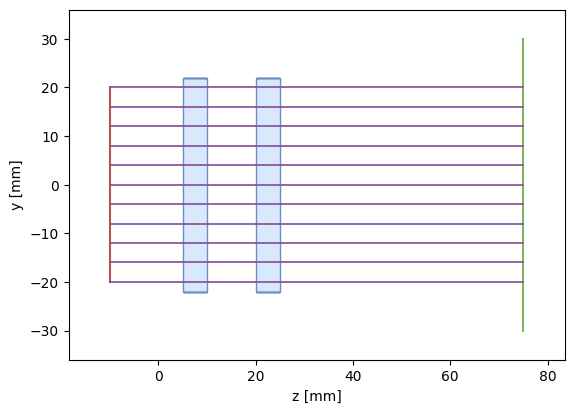

In [7]:
x,weights = source.sample([11],"simpson")
O2,D2,wl,n_func_enviroment,meta_data = system(x,["light_source","lens1","lens2","detector"])
dit.plotting.system2D.plot(system,meta_data)


It's also possible to look at all currently defined bounds with the following code

In [8]:

bounds_numpy = dit.optimize.get_bounds([param for param in system.parameters()],"bounds")
bounds_numpy

named_params = [param for param in system.named_parameters()]
names_params = []
num_elems = []
for name,param in named_params:
    names_params.append(name)
    num_elems.append(torch.prod(torch.tensor(param.shape)))
names_params,num_elems
named_bounds = {}
for k in range(len(names_params)):
    named_bounds[names_params[k]] = bounds_numpy[k]
named_bounds

{'modules_dict.light_source.transform.distance': array([-inf,  inf]),
 'modules_dict.detector.transform.distance': array([  0.,  inf]),
 'modules_dict.detector.transform.parent_transform.distance': array([ 0.,  5.]),
 'modules_dict.detector.transform.parent_transform.parent_transform.distance': array([  0.,  inf]),
 'modules_dict.detector.transform.parent_transform.parent_transform.parent_transform.distance': array([ 0.,  5.]),
 'modules_dict.detector.transform.parent_transform.parent_transform.parent_transform.parent_transform.distance': array([  0.,  inf]),
 'modules_dict.lens1.surface1.surface.curvature': array([-0.04545455,  0.04545455]),
 'modules_dict.lens1.surface1.surface.conic_coeff': array([-inf,  inf]),
 'modules_dict.lens1.surface2.surface.curvature': array([-0.04545455,  0.04545455]),
 'modules_dict.lens1.surface2.surface.conic_coeff': array([-inf,  inf]),
 'modules_dict.lens2.surface1.surface.curvature': array([-0.04545455,  0.04545455]),
 'modules_dict.lens2.surface1.sur

With the LEQZero class one can define a constrain that should be less than or equal zero

In [9]:

def detector_zpos_constraint():
    return det_transform.get_transformation_matrix()[2,3]-75.

constraint_zpos_det = LEQZero(detector_zpos_constraint)
constraints = [constraint_zpos_det]


Below is the source code for running the minimization routine - **<span style="color:red">as of now it is always required to define a callback</span>**

There are a lot of warnings when running the code but they can be ignored - the optimizer will not break even if rays do not find surface intersection due to a bad parameter set

In [10]:
import matplotlib.pyplot as plt

num_rays = 128

def merit_func():
    x,_ = source.sample([num_rays],"midpoint")
    O2,_,_,_,_ = system(x,["light_source","lens1","lens2","detector"])
    out = torch.mean((O2[:,1])**2.0)
    return out

params = system.parameters()
def callback():
    pass
out = dit.minimize(merit_func,system.parameters(),constraints=constraints,tol=1e-6,callback=callback,method="SLSQP",call_before_minimize=True)


Ray intersection FAILED to converge after 100 iterations!
This is totally normal durring optimization when a bad parameterset is chosen.maximum svals are: [tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan), tensor(nan),

With this it possible to obtain the final focussed optical system

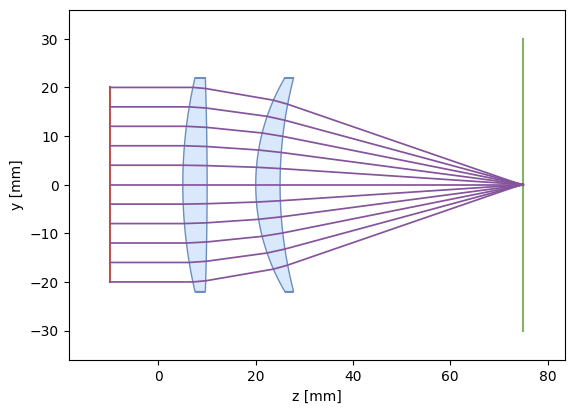

In [11]:
x,weights = source.sample([11],"simpson")
O2,D2,wl,n_func_enviroment,meta_data = system(x,["light_source","lens1","lens2","detector"])
dit.plotting.system2D.plot(system,meta_data)
